In [5]:
import numpy as np

# Task 1
arr = np.ones((5, 5))
arr[1:4, 1:4] = 0

print(arr)

# Task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)

mean = random_data.mean(axis=0)
std  = random_data.std(axis=0)

normalized_data = (random_data - mean) / std

# Task 3
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated theta:", theta_hat)
print("True theta:     ", true_theta)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
Estimated theta: [ 2.51723721 -1.19783796  3.72399266]
True theta:      [ 2.5 -1.2  3.7]


In [8]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1

# Basic info
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

# Fill missing exam_score with mean per major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median per year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

# Task 2

# Average exam score by major
avg_by_major = df.groupby('major')['exam_score'].mean()
print(avg_by_major)

# Major with highest average
print("Best major:", avg_by_major.idxmax())

# Correlation
corr = df['hours_studied'].corr(df['exam_score'])
print(f"Correlation: {corr:.4f}")

# Performance column
def categorize(score):
    if score > 90:   return 'Excellent'
    elif score > 80: return 'Good'
    elif score > 70: return 'Average'
    else:            return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)

# Task 3
# Per major+year combo
summary = df.groupby(['major', 'year']).agg(
    num_students    = ('student_id', 'count'),
    avg_exam_score  = ('exam_score', 'mean'),
    avg_hours       = ('hours_studied', 'mean')
).round(2)
print(summary)

# Top 5 students (ties handled with dense ranking)
df['rank'] = df['exam_score'].rank(method='dense', ascending=False)
top5 = df[df['rank'] <= 5].sort_values('rank')
print(top5[['student_id', 'major', 'year', 'exam_score', 'rank']])

# Pivot table
pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
).round(2)
print(pivot)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   

/tmp/ipykernel_26294/53691557.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1], palette='Set2')


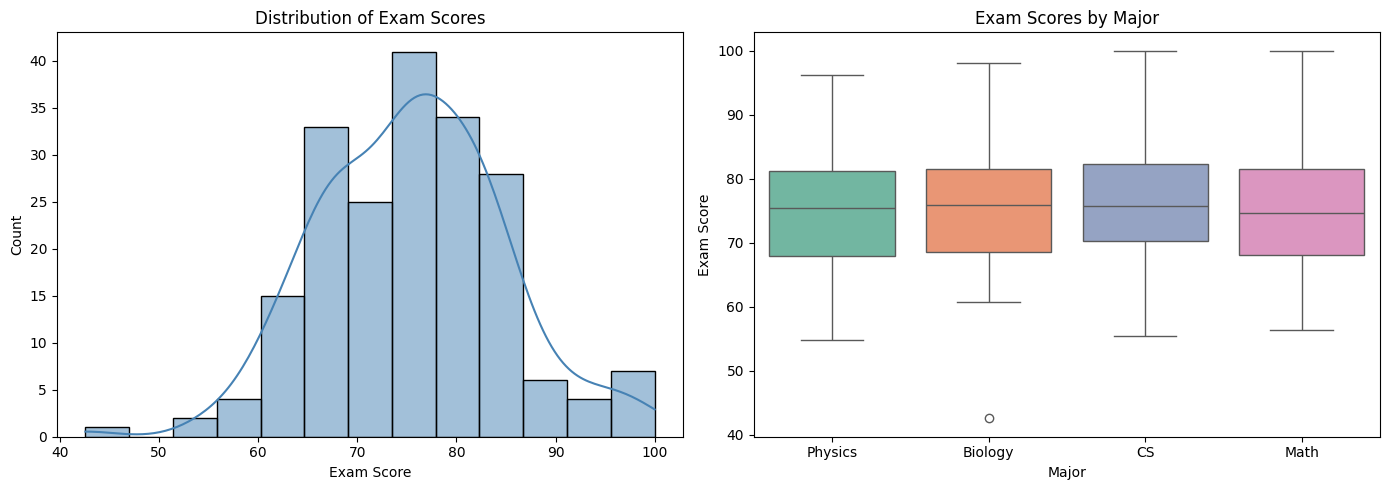

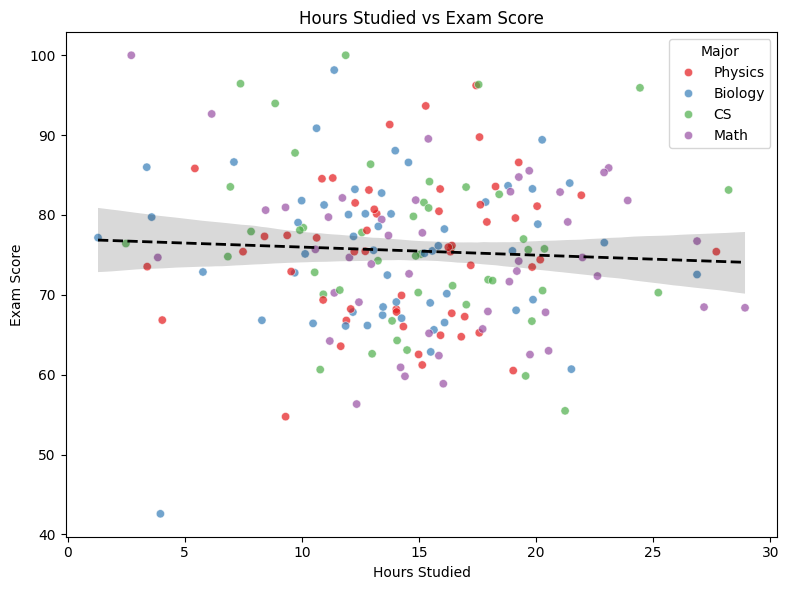

/tmp/ipykernel_26294/53691557.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.index, y=avg_scores.values, ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_26294/53691557.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='year', ax=axes[0, 1], palette='Set1')
/tmp/ipykernel_26294/53691557.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='performance', y='exam_score',


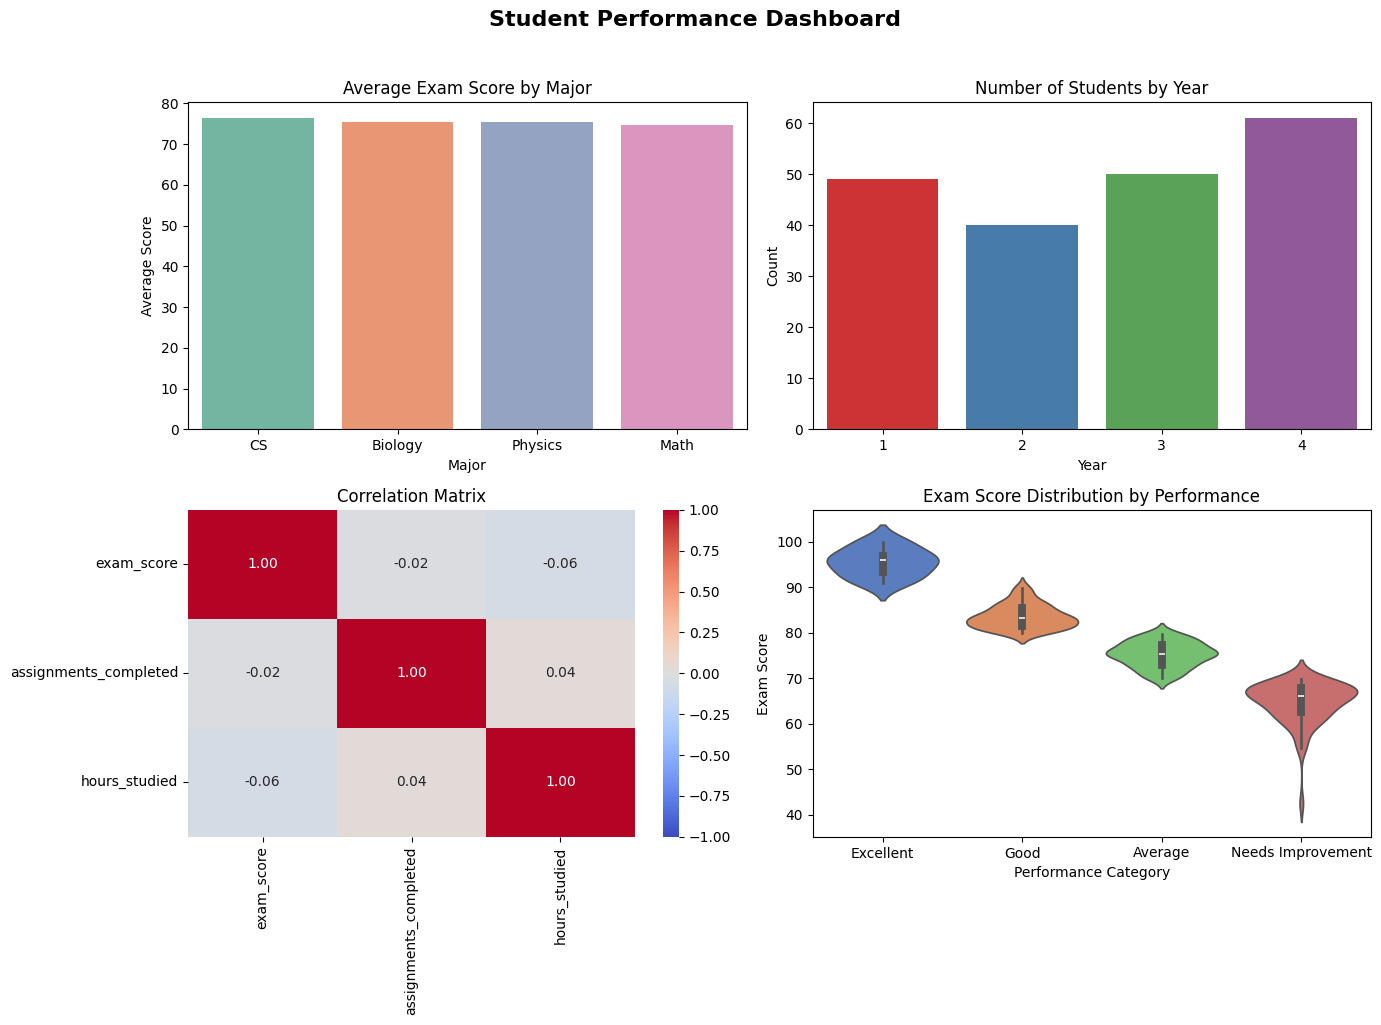

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['exam_score'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')

sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1], palette='Set2')
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

# Task 2
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='hours_studied', y='exam_score',
                hue='major', palette='Set1', alpha=0.7)

sns.regplot(data=df, x='hours_studied', y='exam_score',
            scatter=False, color='black', line_kws={'linewidth': 2, 'linestyle': '--'})

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.tight_layout()
plt.show()

# Task 3
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


avg_scores = df.groupby('major')['exam_score'].mean().sort_values(ascending=False)
sns.barplot(x=avg_scores.index, y=avg_scores.values, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')


sns.countplot(data=df, x='year', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')


num_cols = df[['exam_score', 'assignments_completed', 'hours_studied']].corr()
sns.heatmap(num_cols, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 0], vmin=-1, vmax=1)
axes[1, 0].set_title('Correlation Matrix')


order = ['Excellent', 'Good', 'Average', 'Needs Improvement']
sns.violinplot(data=df, x='performance', y='exam_score',
               order=order, ax=axes[1, 1], palette='muted')
axes[1, 1].set_title('Exam Score Distribution by Performance')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')

plt.suptitle('Student Performance Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

           num_customers  avg_income  avg_CLV  total_CLV
age_group                                               
18-25                 81    50634.02   718.37   58188.06
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

Top 10% CLV threshold: $1222.94
Number of top customers: 50


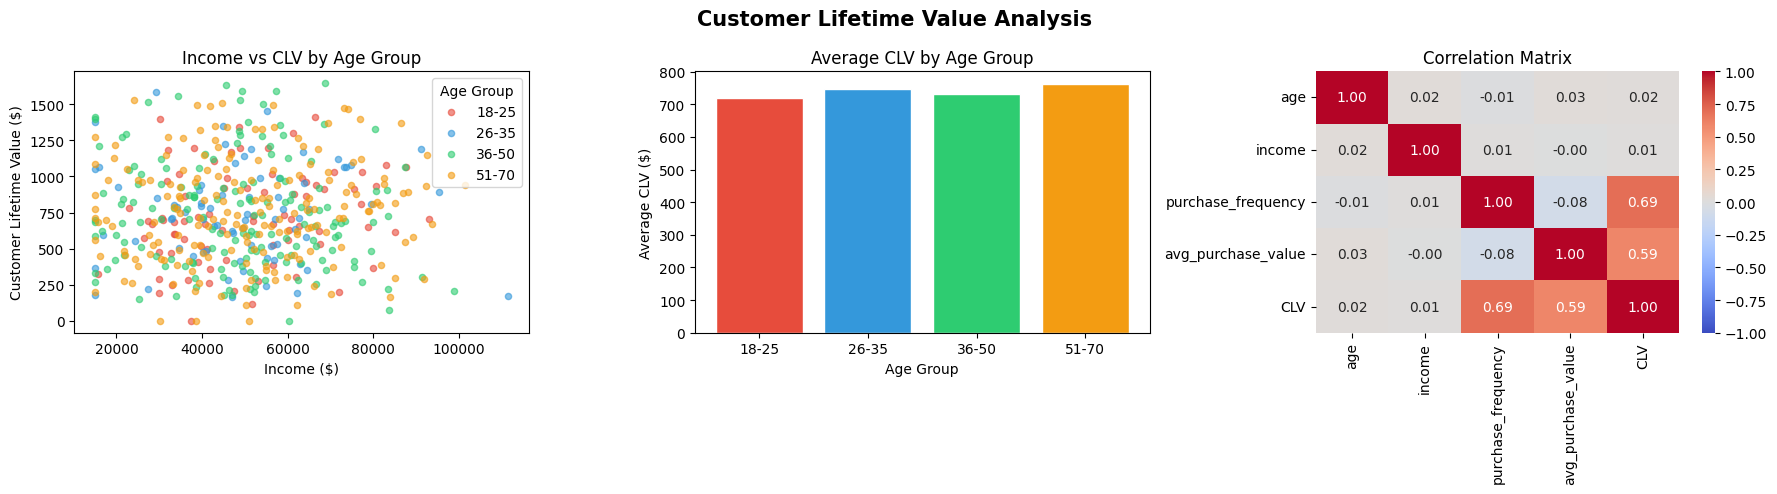

In [15]:

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


# CLV calculation
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = (customers['purchase_frequency'] *
                    customers['avg_purchase_value'] *
                    (1 + customers['churn_risk']))

# Age groups
bins   = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins,
                                labels=labels, include_lowest=True)

# Group analysis

# Per age group stats
age_group_stats = customers.groupby('age_group', observed=True).agg(
    num_customers = ('age',         'count'),
    avg_income    = ('income',      'mean'),
    avg_CLV       = ('CLV',         'mean'),
    total_CLV     = ('CLV',         'sum')
).round(2)
print(age_group_stats)

# Top 10% by CLV
threshold    = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= threshold]
print(f"\nTop 10% CLV threshold: ${threshold:.2f}")
print(f"Number of top customers: {len(top_customers)}")

# Visualizations

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter: income vs CLV colored by age group
palette = {'18-25': '#e74c3c', '26-35': '#3498db',
           '36-50': '#2ecc71', '51-70': '#f39c12'}
for group, subset in customers.groupby('age_group', observed=True):
    axes[0].scatter(subset['income'], subset['CLV'],
                    label=group, alpha=0.6, color=palette[group], s=20)
axes[0].set_title('Income vs CLV by Age Group')
axes[0].set_xlabel('Income ($)')
axes[0].set_ylabel('Customer Lifetime Value ($)')
axes[0].legend(title='Age Group')

# 2. Bar: average CLV by age group
axes[1].bar(age_group_stats.index, age_group_stats['avg_CLV'],
            color=palette.values(), edgecolor='white')
axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV ($)')

# 3. Correlation heatmap
corr_cols = ['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']
corr = customers[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2], vmin=-1, vmax=1)
axes[2].set_title('Correlation Matrix')

plt.suptitle('Customer Lifetime Value Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
"At the end of the day, loyalty is about habits, not demographics. It doesn't matter how old someone is or what they earn; what matters is how often they show up for us."
"Our most loyal 10% aren't defined by an age group—they’re just the regulars who keep coming back."

"What we do next:"

"- Celebrate the regulars: Focus our energy on the people who buy often, regardless of their age or background."

"- Reward the habit: Design a loyalty program that says 'thanks for coming back' rather than just 'thanks for spending a lot today'."

"- Check in on the quiet ones: Figure out why some folks buy once and drift away, and fix whatever is making them lose touch."